# Multi-Station Reanalysis Pipeline — LSTM + EnKF

Creates reanalysis datasets for Peace River water quality stations by fusing
hydrological model simulations with USGS/FDEP observations using an
**LSTM neural network** as the dynamical forecast operator and the
**Ensemble Kalman Filter (EnKF)** for data assimilation.

**Stations:**
- 02296750 (Arcadia) — Discharge, TN, TP
- 270318081593100 (Ft Ogden RM14.82) — TN, TP only
- 02297330 (Ft Ogden) — TN, TP only

**Intermittent assimilation:** TN/TP observations are sparse (monthly).
The EnKF only performs the analysis step on days with observations;
on all other days the ensemble propagates forward with the LSTM + process noise.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import tensorflow as tf

# Ensure src/ is importable
sys.path.insert(0, os.path.abspath("."))

from src.config import load_config, resolve_path
from src.data_loader import load_model_data, load_observations, check_data_availability
from src.pipeline import run_single_reanalysis

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow {tf.__version__}")
print(f"Seed: {SEED}")

TensorFlow 2.20.0
Seed: 42


## Step 1 — Load Configuration

In [2]:
CONFIG_PATH = os.path.join("configs", "pipeline_config.yaml")
config = load_config(CONFIG_PATH)

CONFIG_DIR = os.path.dirname(os.path.abspath(CONFIG_PATH))
MODEL_DIR = resolve_path(CONFIG_DIR, config["paths"]["model_data_dir"])
OBS_DIR = resolve_path(CONFIG_DIR, config["paths"]["observation_data_dir"])
OUTPUT_DIR = resolve_path(CONFIG_DIR, config["paths"]["output_dir"])
PARAMS = config["hyperparameters"]

# Directory lookup for obs entries that override the default obs directory
DIRS = {
    "model_data_dir": MODEL_DIR,
    "observation_data_dir": OBS_DIR,
}

print(f"Model data : {MODEL_DIR}")
print(f"Obs data   : {OBS_DIR}")
print(f"Output dir : {OUTPUT_DIR}")
print(f"\nHyperparameters:")
for k, v in PARAMS.items():
    print(f"  {k}: {v}")

Model data : c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Model_Data
Obs data   : c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Observation_Data
Output dir : c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs

Hyperparameters:
  lookback: 12
  lstm_units: 64
  dense_units: 64
  learning_rate: 0.001
  batch_size: 32
  epochs: 200
  patience: 15
  n_ensemble: 50
  obs_error_factor: 0.2
  train_fraction: 0.8
  min_overlap_days: 30


## Step 2 — Data Availability Scan

Check which station-variable pairs have sufficient observation data
before running any reanalysis.

In [3]:
availability = check_data_availability(config, CONFIG_DIR)
display(availability)

# Save summary
summary_dir = os.path.join(OUTPUT_DIR, "summary")
os.makedirs(summary_dir, exist_ok=True)
availability.to_csv(os.path.join(summary_dir, "data_availability.csv"), index=False)
print(f"\nSaved → {summary_dir}/data_availability.csv")

,station_id,station_name,variable,model_start,model_end,obs_count,obs_start,obs_end,overlap_days,status
0,02296750,Arcadia,discharge,1999-01-01,2023-12-31,10592,1995-01-01,2023-12-31,9131,GO
1,02296750,Arcadia,TN,1999-01-01,2023-12-31,275,1970-06-12,2004-09-29,41,GO
2,02296750,Arcadia,TP,1999-01-01,2023-12-31,353,1939-10-31,2004-09-29,41,GO
3,270318081593100,FtOgden_RM1482,discharge,NaN,NaN,0,NaN,NaN,0,NO OBS
4,270318081593100,FtOgden_RM1482,TN,1999-01-01,2023-12-31,47,1996-08-26,2000-06-27,18,LOW OVERLAP (18 < 30)
5,270318081593100,FtOgden_RM1482,TP,1999-01-01,2023-12-31,47,1996-08-26,2000-06-27,18,LOW OVERLAP (18 < 30)
6,02297330,FtOgden,discharge,NaN,NaN,0,NaN,NaN,0,NO OBS
7,02297330,FtOgden,TN,1999-01-01,2023-12-31,0,NaN,NaN,0,NO OBS
8,02297330,FtOgden,TP,1999-01-01,2023-12-31,0,NaN,NaN,0,NO OBS



Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\summary/data_availability.csv


## Step 3 — Run Reanalysis for All Viable Station-Variable Pairs

Loops over all stations and variables. Skips pairs with no observations
or insufficient overlap.

In [4]:
results = []
plot_data = {}  # (variable, station_name) -> dict of arrays for cross-station plots
min_overlap = PARAMS["min_overlap_days"]

for st_cfg in config["stations"]:
    station_id = st_cfg["station_id"]
    station_name = st_cfg["name"]
    model_path = os.path.join(MODEL_DIR, st_cfg["model_file"])

    for variable in ["discharge", "TN", "TP"]:
        obs_cfg = st_cfg["observations"].get(variable)

        if obs_cfg is None:
            print(f"\nSKIP: {station_name}/{variable} — no observations configured")
            continue

        # Load data
        model_df = load_model_data(model_path, variable)
        obs_df = load_observations(OBS_DIR, obs_cfg, dirs=DIRS)

        if len(obs_df.dropna()) < min_overlap:
            print(f"\nSKIP: {station_name}/{variable} — only {len(obs_df.dropna())} obs (need {min_overlap})")
            continue

        # Output directory for this station-variable
        var_output_dir = os.path.join(OUTPUT_DIR, f"{station_id}_{station_name}", variable)

        result = run_single_reanalysis(
            model_df=model_df,
            obs_df=obs_df,
            variable=variable,
            station_name=station_name,
            output_dir=var_output_dir,
            hyperparams=PARAMS,
            seed=SEED,
        )
        results.append(result)

        # Collect data for cross-station CI plots
        rean_mean_path = os.path.join(var_output_dir, f"reanalysis_{variable}_mean.csv")
        ens_path = os.path.join(var_output_dir, f"reanalysis_{variable}_ensemble.csv")
        obs_path = os.path.join(var_output_dir, f"obs_{variable}.csv")

        rean_mean_df = pd.read_csv(rean_mean_path, parse_dates=["time"], index_col="time")
        ens_df = pd.read_csv(ens_path, parse_dates=["time"])
        obs_out_df = pd.read_csv(obs_path, parse_dates=["time"], index_col="time")

        # Pivot ensemble to (T, M) array
        ens_pivot = ens_df.pivot(index="time", columns="member", values=variable)
        ens_arr = ens_pivot.values
        ci_lower = np.percentile(ens_arr, 2.5, axis=1)
        ci_upper = np.percentile(ens_arr, 97.5, axis=1)

        plot_data[(variable, station_name)] = {
            "time_idx": rean_mean_df.index,
            "rean_mean": rean_mean_df[variable].values,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
            "obs": obs_out_df[variable].values,
            "ci_integral": result["ci_integral"],
            "station_id": station_id,
        }

print(f"\n{'='*70}")
print(f"  Completed {len(results)} reanalysis runs")
print(f"{'='*70}")


  Reanalysis: Arcadia — discharge
  Model: 9131 daily rows (1999-01-01 → 2023-12-31)
  Observations: 10592 records (dense)
  Overlap: 9131 common days
  Time series length: 9131 days
  Sequences: 9119 total, 7295 train, 1824 val


c:\Users\John\anaconda3\envs\week3_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  LSTM trained — stopped at epoch 74, best val_loss=0.007037
  Q = 0.002286 (std=0.0478), R = 0.200022 (std=0.4472)
  Running EnKF — 50 members × 9131 steps...
  t = 2,000/9,131  |  K=0.3136
  t = 4,000/9,131  |  K=0.5656
  t = 6,000/9,131  |  K=0.4702
  t = 8,000/9,131  |  K=0.7242
  EnKF complete.
  Running open-loop baseline...
  Open-loop t = 2,000/9,131
  Open-loop t = 4,000/9,131
  Open-loop t = 6,000/9,131
  Open-loop t = 8,000/9,131
  Open-loop complete.
  95% CI integral: 553,451.38, mean width: 60.6156
  Saved CSVs to c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\02296750_Arcadia\discharge
  Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\02296750_Arcadia\discharge\discharge_Comparison.png
  Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\02296750_Arcadia\discharge\CI_Area_discharge.png
  Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Rean

c:\Users\John\anaconda3\envs\week3_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  LSTM trained — stopped at epoch 21, best val_loss=0.036329
  Q = 0.006714 (std=0.0819), R = 0.205000 (std=0.4528)
  Running EnKF — 50 members × 9131 steps...
  t = 2,000/9,131  |  no obs
  t = 4,000/9,131  |  no obs
  t = 6,000/9,131  |  no obs
  t = 8,000/9,131  |  no obs
  EnKF complete.
  Running open-loop baseline...
  Open-loop t = 2,000/9,131
  Open-loop t = 4,000/9,131
  Open-loop t = 6,000/9,131
  Open-loop t = 8,000/9,131
  Open-loop complete.
  95% CI integral: 10,939.34, mean width: 1.1981
  Saved CSVs to c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\02296750_Arcadia\TN
  Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\02296750_Arcadia\TN\TN_Comparison.png
  Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\02296750_Arcadia\TN\CI_Area_TN.png
  Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\02296750_Arcadia\TN\M

...

  LSTM trained — stopped at epoch 26, best val_loss=0.010103
  Q = 0.003793 (std=0.0616), R = 0.205000 (std=0.4528)
  Running EnKF — 50 members × 9131 steps...
  t = 2,000/9,131  |  no obs
  t = 4,000/9,131  |  no obs
  t = 6,000/9,131  |  no obs
  t = 8,000/9,131  |  no obs
  EnKF complete.
  Running open-loop baseline...
  Open-loop t = 2,000/9,131
  Open-loop t = 4,000/9,131
  Open-loop t = 6,000/9,131
  Open-loop t = 8,000/9,131
  Open-loop complete.
  95% CI integral: 10,150.83, mean width: 1.1118
  Saved CSVs to c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\02296750_Arcadia\TP
  Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\02296750_Arcadia\TP\TP_Comparison.png
  Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\02296750_Arcadia\TP\CI_Area_TP.png
  Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\02296750_Arcadia\TP\M

c:\Users\John\anaconda3\envs\week3_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  LSTM trained — stopped at epoch 46, best val_loss=0.019942
  Q = 0.000229 (std=0.0151), R = 0.211765 (std=0.4602)
  Running EnKF — 50 members × 9131 steps...
  t = 2,000/9,131  |  no obs
  t = 4,000/9,131  |  no obs
  t = 6,000/9,131  |  no obs
  t = 8,000/9,131  |  no obs
  EnKF complete.
  Running open-loop baseline...
  Open-loop t = 2,000/9,131
  Open-loop t = 4,000/9,131
  Open-loop t = 6,000/9,131
  Open-loop t = 8,000/9,131
  Open-loop complete.
  95% CI integral: 2,774.11, mean width: 0.3038
  Saved CSVs to c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\270318081593100_FtOgden_RM1482\TN
  Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\270318081593100_FtOgden_RM1482\TN\TN_Comparison.png
  Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\270318081593100_FtOgden_RM1482\TN\CI_Area_TN.png
  Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalys

c:\Users\John\anaconda3\envs\week3_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  LSTM trained — stopped at epoch 108, best val_loss=0.038649
  Q = 0.008824 (std=0.0939), R = 0.211765 (std=0.4602)
  Running EnKF — 50 members × 9131 steps...
  t = 2,000/9,131  |  no obs
  t = 4,000/9,131  |  no obs
  t = 6,000/9,131  |  no obs
  t = 8,000/9,131  |  no obs
  EnKF complete.
  Running open-loop baseline...
  Open-loop t = 2,000/9,131
  Open-loop t = 4,000/9,131
  Open-loop t = 6,000/9,131
  Open-loop t = 8,000/9,131
  Open-loop complete.
  95% CI integral: 3,179.43, mean width: 0.3482
  Saved CSVs to c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\270318081593100_FtOgden_RM1482\TP
  Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\270318081593100_FtOgden_RM1482\TP\TP_Comparison.png
  Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\270318081593100_FtOgden_RM1482\TP\CI_Area_TP.png
  Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanaly

## Step 4 — Summary Table

In [5]:
if results:
    summary_df = pd.DataFrame(results)
    display(summary_df)

    summary_df.to_csv(os.path.join(summary_dir, "ci_integral_summary.csv"), index=False)
    print(f"Saved → {summary_dir}/ci_integral_summary.csv")
else:
    print("No reanalysis runs completed.")

,station,variable,T,obs_count,is_sparse,Q,R,best_val_loss,stopped_epoch,ci_integral,ci_mean_width,ci_max_width
0,Arcadia,discharge,9131,9131,False,0.002286,0.200022,0.007037,74,553451.382392,60.615607,118.661824
1,Arcadia,TN,9131,41,True,0.006714,0.205000,0.036329,21,10939.343521,1.198117,1.619373
2,Arcadia,TP,9131,41,True,0.003793,0.205000,0.010103,26,10150.827620,1.111757,2.452428
3,FtOgden_RM1482,TN,9131,18,True,0.000229,0.211765,0.019942,46,2774.112494,0.303834,0.456071
4,FtOgden_RM1482,TP,9131,18,True,0.008824,0.211765,0.038649,108,3179.432178,0.348224,2.238334


Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\summary/ci_integral_summary.csv


## Step 5 — Cross-Station 95 % CI Area Plots (Consistent Y-Axes)

For each variable (Discharge, TN, TP), plot the 95 % CI shaded region and
reanalysis mean for every station that ran that variable. All panels within
a variable share the same y-axis limits so differences in uncertainty are
visually comparable.

Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\summary\Cross_Station_CI_discharge.png


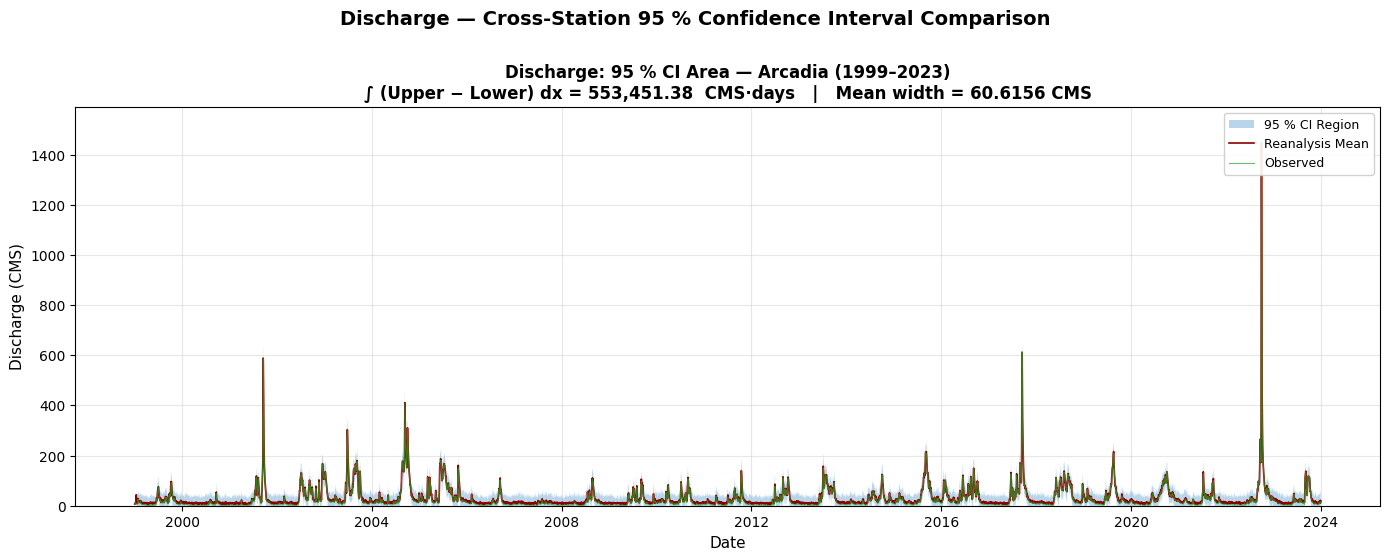

Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\summary\Cross_Station_CI_TN.png


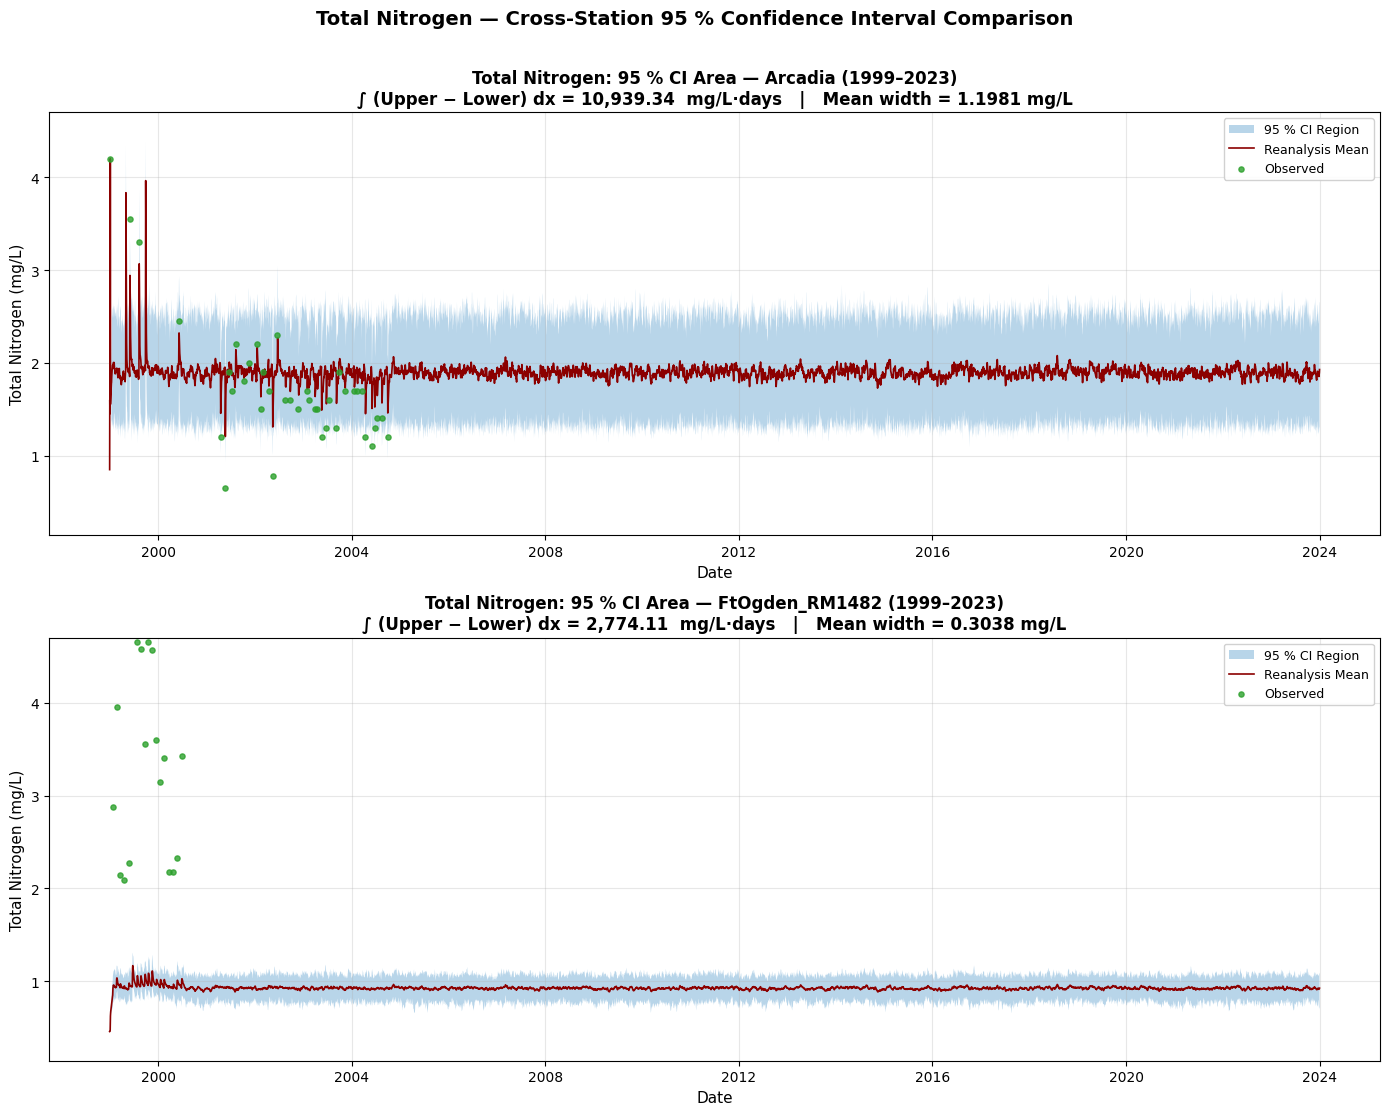

Saved → c:\Users\John\Desktop\School\1_Senior_Project\Sprint_2\Reanalysis_Pipeline\outputs\summary\Cross_Station_CI_TP.png


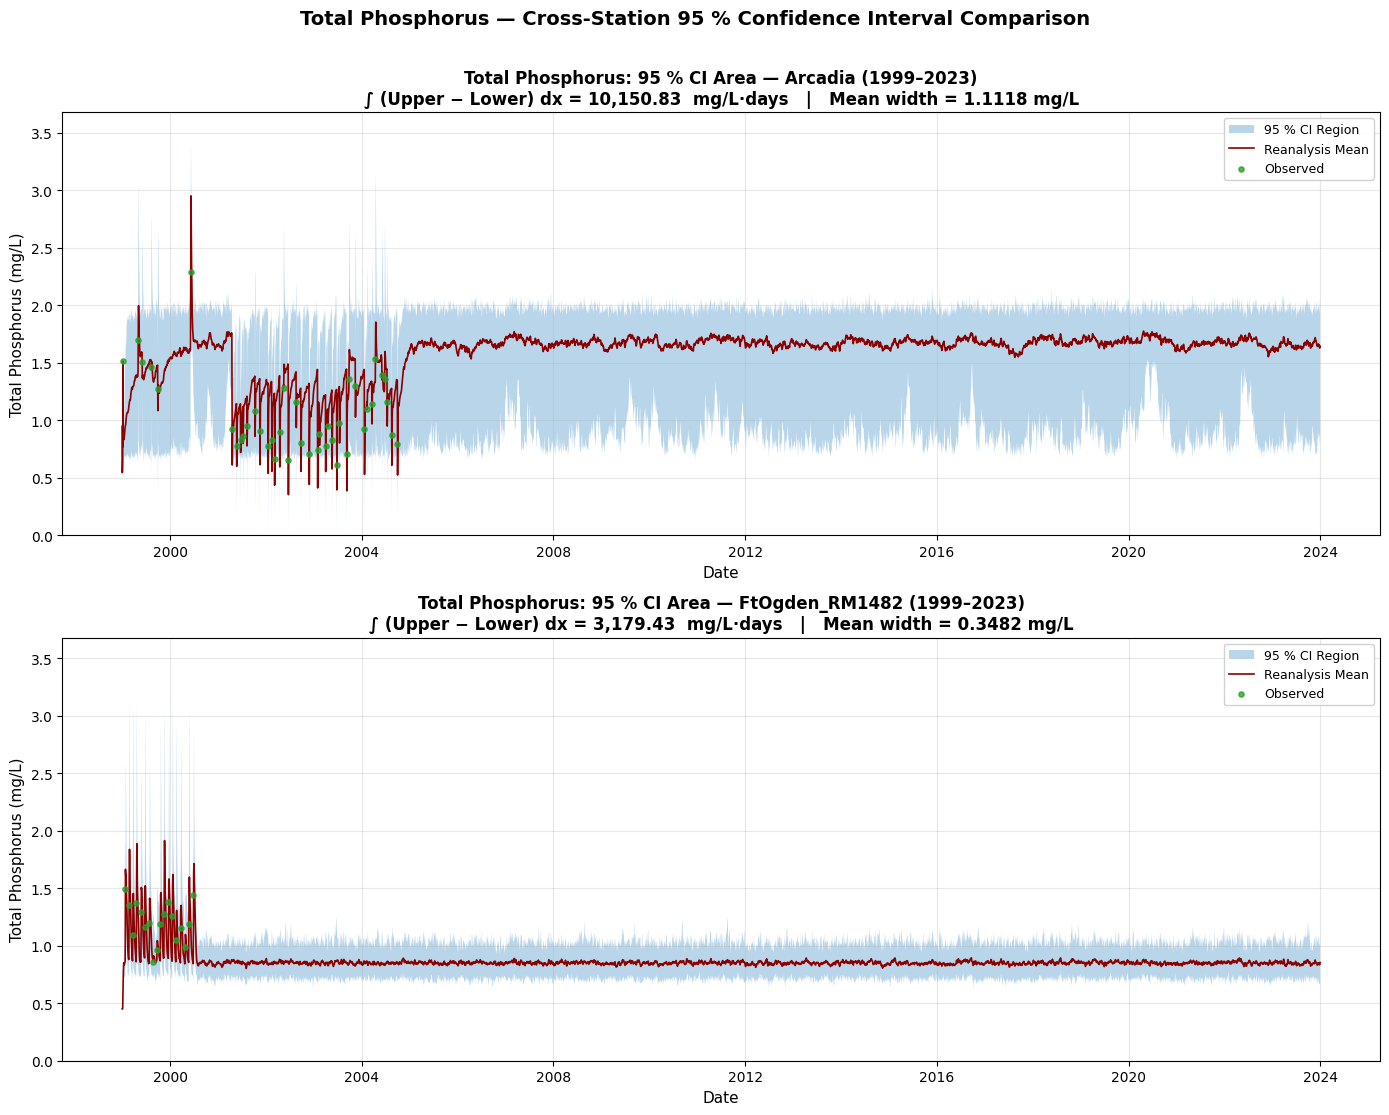


Pipeline complete.


In [6]:
import matplotlib.pyplot as plt
from scipy import integrate

UNITS = {"discharge": "CMS", "TN": "mg/L", "TP": "mg/L"}
LABELS = {"discharge": "Discharge", "TN": "Total Nitrogen", "TP": "Total Phosphorus"}

for variable in ["discharge", "TN", "TP"]:
    # Gather all stations that have this variable
    station_entries = [
        (sname, plot_data[(variable, sname)])
        for (var, sname) in plot_data if var == variable
    ]
    if not station_entries:
        continue

    n_stations = len(station_entries)
    unit = UNITS[variable]
    label = LABELS[variable]

    # Compute global y-limits across all stations for this variable
    y_min = min(d["ci_lower"].min() for _, d in station_entries)
    y_max = max(d["ci_upper"].max() for _, d in station_entries)
    y_pad = (y_max - y_min) * 0.08
    y_lo = max(0, y_min - y_pad)  # don't go below 0 for physical quantities
    y_hi = y_max + y_pad

    fig, axes = plt.subplots(n_stations, 1, figsize=(14, 5.5 * n_stations),
                             squeeze=False, sharex=False)

    for i, (station_name, d) in enumerate(station_entries):
        ax = axes[i, 0]
        time_idx = d["time_idx"]
        ci_lower = d["ci_lower"]
        ci_upper = d["ci_upper"]
        rean_mean = d["rean_mean"]
        obs = d["obs"]
        ci_integral = d["ci_integral"]

        ci_width = ci_upper - ci_lower

        # Shaded 95% CI region
        ax.fill_between(
            time_idx, ci_lower, ci_upper,
            color="#7FB3D8", alpha=0.55, edgecolor="none", label="95 % CI Region",
        )

        # Reanalysis mean
        ax.plot(time_idx, rean_mean, color="#8B0000", linewidth=1.2,
                label="Reanalysis Mean")

        # Observations (scatter for sparse, line for dense)
        obs_valid = ~np.isnan(obs)
        if obs_valid.sum() < len(obs) * 0.5:
            ax.scatter(time_idx[obs_valid], obs[obs_valid],
                       s=14, color="#2ca02c", alpha=0.8, zorder=3,
                       label="Observed")
        else:
            ax.plot(time_idx, obs, color="#2ca02c", linewidth=0.8,
                    alpha=0.7, label="Observed")

        # Consistent y-axis
        ax.set_ylim(y_lo, y_hi)

        start_yr = time_idx.min().year
        end_yr = time_idx.max().year
        ax.set_xlabel("Date", fontsize=11)
        ax.set_ylabel(f"{label} ({unit})", fontsize=11)
        ax.set_title(
            f"{label}: 95 % CI Area — {station_name} ({start_yr}–{end_yr})\n"
            f"∫ (Upper − Lower) dx = {ci_integral:,.2f}  {unit}·days   |   "
            f"Mean width = {ci_width.mean():.4f} {unit}",
            fontsize=12, fontweight="bold",
        )
        ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
        ax.grid(True, alpha=0.3)

    fig.suptitle(
        f"{label} — Cross-Station 95 % Confidence Interval Comparison",
        fontsize=14, fontweight="bold", y=1.01,
    )
    plt.tight_layout()
    path = os.path.join(summary_dir, f"Cross_Station_CI_{variable}.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved → {path}")
    plt.show()

print("\nPipeline complete.")